Let's imagine we have 6 data points in a 2D space:

A = (1, 1)
B = (1, 2)
C = (2, 1)
D = (5, 4)
E = (5, 5)
F = (6, 4)

Our goal is to cluster these points into k=2 clusters.

In [1]:
import numpy as np
import pandas as pd

points = {
    'A': np.array([1, 1]),
    'B': np.array([1, 2]),
    'C': np.array([2, 1]),
    'D': np.array([5, 4]),
    'E': np.array([5, 5]),
    'F': np.array([6, 4])
}

C1 = np.array([1, 1])
C2 = np.array([5, 4])

print("Data Points:")
for name, point in points.items():
    print(f"  {name} = {tuple(point)}")
    
print(f"\nInitial Centroids:")
print(f"  C1 = {tuple(C1)}")
print(f"  C2 = {tuple(C2)}")

Data Points:
  A = (np.int64(1), np.int64(1))
  B = (np.int64(1), np.int64(2))
  C = (np.int64(2), np.int64(1))
  D = (np.int64(5), np.int64(4))
  E = (np.int64(5), np.int64(5))
  F = (np.int64(6), np.int64(4))

Initial Centroids:
  C1 = (np.int64(1), np.int64(1))
  C2 = (np.int64(5), np.int64(4))


I'll define two functions now. One will be the euclidian distance, which will measure the distance between two points, and the other one will be the assignment function, which will assign each point to the nearest centroid.

In [2]:
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

def assign_clusters(points, C1, C2, verbose=True):
    cluster1 = []
    cluster2 = []
    
    if verbose:
        print("Distance calculations:")
        print("-" * 70)
    
    for name, point in points.items():
        dist_to_C1 = euclidean_distance(point, C1)
        dist_to_C2 = euclidean_distance(point, C2)
        
        if verbose:
            print(f"{name}{tuple(point)}: d(C1)={dist_to_C1:.4f}, d(C2)={dist_to_C2:.4f}", end="")
        
        if dist_to_C1 < dist_to_C2:
            cluster1.append((name, point))
            if verbose:
                print(f" → Assigned to Cluster 1")
        else:
            cluster2.append((name, point))
            if verbose:
                print(f" → Assigned to Cluster 2")
    
    return cluster1, cluster2

def update_centroids(cluster1, cluster2, verbose=True):
    new_C1 = np.mean([point for _, point in cluster1], axis=0)
    new_C2 = np.mean([point for _, point in cluster2], axis=0)
    
    if verbose:
        print("\nCalculating new centroids:")
        print("-" * 70)
        cluster1_coords = [tuple(p) for _, p in cluster1]
        cluster2_coords = [tuple(p) for _, p in cluster2]
        
        print(f"C1 = mean of {', '.join([name for name, _ in cluster1])}")
        print(f"   = {cluster1_coords}")
        print(f"   = ({sum(p[0] for _, p in cluster1)}/{len(cluster1)}, "
              f"{sum(p[1] for _, p in cluster1)}/{len(cluster1)})")
        print(f"   = {tuple(new_C1)}")
        
        print(f"\nC2 = mean of {', '.join([name for name, _ in cluster2])}")
        print(f"   = {cluster2_coords}")
        print(f"   = ({sum(p[0] for _, p in cluster2)}/{len(cluster2)}, "
              f"{sum(p[1] for _, p in cluster2)}/{len(cluster2)})")
        print(f"   = {tuple(new_C2)}")
    
    return new_C1, new_C2

*Iteration 1:*

Assignment

In [3]:
print(f"Current centroids: C1={tuple(C1)}, C2={tuple(C2)}\n")

cluster1_iter1, cluster2_iter1 = assign_clusters(points, C1, C2)

Current centroids: C1=(np.int64(1), np.int64(1)), C2=(np.int64(5), np.int64(4))

Distance calculations:
----------------------------------------------------------------------
A(np.int64(1), np.int64(1)): d(C1)=0.0000, d(C2)=5.0000 → Assigned to Cluster 1
B(np.int64(1), np.int64(2)): d(C1)=1.0000, d(C2)=4.4721 → Assigned to Cluster 1
C(np.int64(2), np.int64(1)): d(C1)=1.0000, d(C2)=4.2426 → Assigned to Cluster 1
D(np.int64(5), np.int64(4)): d(C1)=5.0000, d(C2)=0.0000 → Assigned to Cluster 2
E(np.int64(5), np.int64(5)): d(C1)=5.6569, d(C2)=1.0000 → Assigned to Cluster 2
F(np.int64(6), np.int64(4)): d(C1)=5.8310, d(C2)=1.0000 → Assigned to Cluster 2


Update

In [4]:
C1, C2 = update_centroids(cluster1_iter1, cluster2_iter1)


Calculating new centroids:
----------------------------------------------------------------------
C1 = mean of A, B, C
   = [(np.int64(1), np.int64(1)), (np.int64(1), np.int64(2)), (np.int64(2), np.int64(1))]
   = (4/3, 4/3)
   = (np.float64(1.3333333333333333), np.float64(1.3333333333333333))

C2 = mean of D, E, F
   = [(np.int64(5), np.int64(4)), (np.int64(5), np.int64(5)), (np.int64(6), np.int64(4))]
   = (16/3, 13/3)
   = (np.float64(5.333333333333333), np.float64(4.333333333333333))


*Iteration 2*

Assignment

In [5]:
print(f"Current centroids: C1={tuple(C1)}, C2={tuple(C2)}\n")

cluster1_iter2, cluster2_iter2 = assign_clusters(points, C1, C2)

Current centroids: C1=(np.float64(1.3333333333333333), np.float64(1.3333333333333333)), C2=(np.float64(5.333333333333333), np.float64(4.333333333333333))

Distance calculations:
----------------------------------------------------------------------
A(np.int64(1), np.int64(1)): d(C1)=0.4714, d(C2)=5.4671 → Assigned to Cluster 1
B(np.int64(1), np.int64(2)): d(C1)=0.7454, d(C2)=4.9216 → Assigned to Cluster 1
C(np.int64(2), np.int64(1)): d(C1)=0.7454, d(C2)=4.7140 → Assigned to Cluster 1
D(np.int64(5), np.int64(4)): d(C1)=4.5338, d(C2)=0.4714 → Assigned to Cluster 2
E(np.int64(5), np.int64(5)): d(C1)=5.1854, d(C2)=0.7454 → Assigned to Cluster 2
F(np.int64(6), np.int64(4)): d(C1)=5.3748, d(C2)=0.7454 → Assigned to Cluster 2


Update

In [6]:
C1_final, C2_final = update_centroids(cluster1_iter2, cluster2_iter2)


Calculating new centroids:
----------------------------------------------------------------------
C1 = mean of A, B, C
   = [(np.int64(1), np.int64(1)), (np.int64(1), np.int64(2)), (np.int64(2), np.int64(1))]
   = (4/3, 4/3)
   = (np.float64(1.3333333333333333), np.float64(1.3333333333333333))

C2 = mean of D, E, F
   = [(np.int64(5), np.int64(4)), (np.int64(5), np.int64(5)), (np.int64(6), np.int64(4))]
   = (16/3, 13/3)
   = (np.float64(5.333333333333333), np.float64(4.333333333333333))


Now let's compare the cluster assignments between the two iterations to see if the algorithm has converged.

In [7]:
cluster1_names_iter1 = set([name for name, _ in cluster1_iter1])
cluster1_names_iter2 = set([name for name, _ in cluster1_iter2])
cluster2_names_iter1 = set([name for name, _ in cluster2_iter1])
cluster2_names_iter2 = set([name for name, _ in cluster2_iter2])

comparison_data = {
    'Iteration 1': [
        ', '.join(sorted(cluster1_names_iter1)),
        ', '.join(sorted(cluster2_names_iter1))
    ],
    'Iteration 2': [
        ', '.join(sorted(cluster1_names_iter2)),
        ', '.join(sorted(cluster2_names_iter2))
    ]
}

df = pd.DataFrame(comparison_data, index=['Cluster 1', 'Cluster 2'])
print("\n")
print(df)

if cluster1_names_iter1 == cluster1_names_iter2:
    print("CONVERGENCE ACHIEVED!")
    print("Cluster assignments did NOT change between iterations.")
    print("The algorithm has converged after just 2 iterations!")
else:
    print("NOT CONVERGED YET")
    print("Cluster assignments CHANGED between iterations.")
    print("More iterations would be needed for convergence.")



          Iteration 1 Iteration 2
Cluster 1     A, B, C     A, B, C
Cluster 2     D, E, F     D, E, F
CONVERGENCE ACHIEVED!
Cluster assignments did NOT change between iterations.
The algorithm has converged after just 2 iterations!


Now we'll use Scikit-learn to perform K-Means on a simple, synthetic dataset that we generate ourselves.

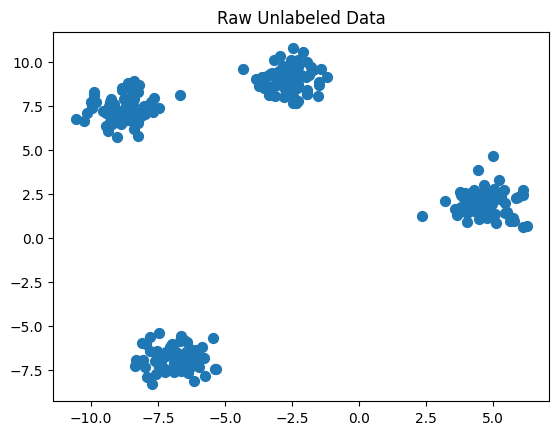

In [8]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs 
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.7, random_state=42)
plt.scatter(X[:, 0], X[:, 1], s=50) 
plt.title('Raw Unlabeled Data') 
plt.show()

Now let's train and the K-Means model.

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


Now that the model is trained, let's visualize the results.

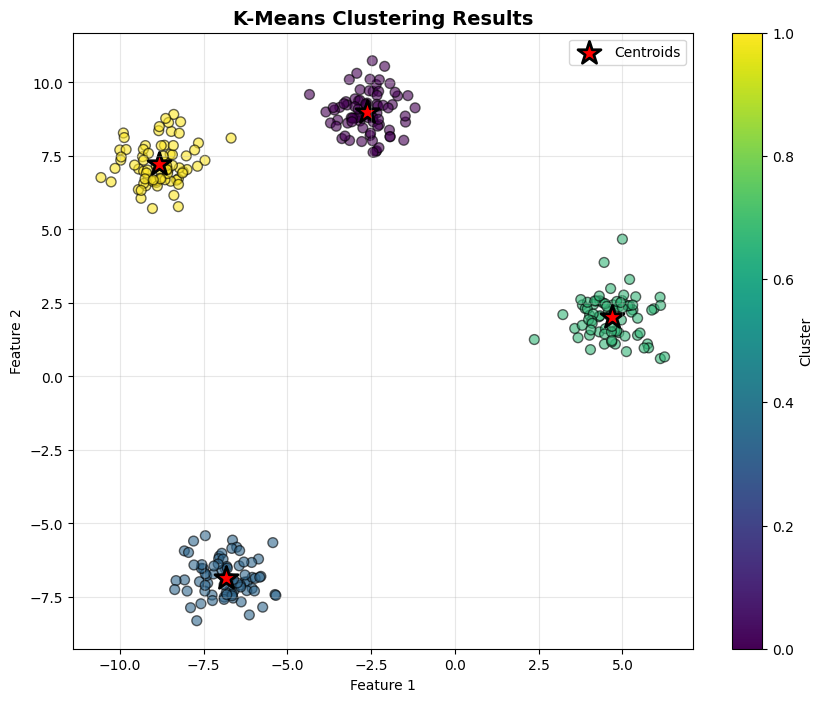

In [12]:
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=50, 
           cmap='viridis', alpha=0.6, edgecolors='k')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
           c='red', s=300, marker='*', edgecolors='black', linewidths=2,
           label='Centroids')

plt.title('K-Means Clustering Results', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.colorbar(label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

Ok, everything works perfectly. However, it turns out we cheated in this exercise, as we already knew that the data had 4 clusters. In the real world we don't know this, so let's use the Elbow method to find the optimal k.

In [19]:
wcss = []
k_range = range(1, 11)

np.random.seed(42)
X = np.vstack([
    np.random.randn(100, 2) + [2, 2],
    np.random.randn(100, 2) + [-2, -2],
    np.random.randn(100, 2) + [2, -2],
    np.random.randn(100, 2) + [-2, 2]
])

The loop:

In [20]:
for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

The plot:

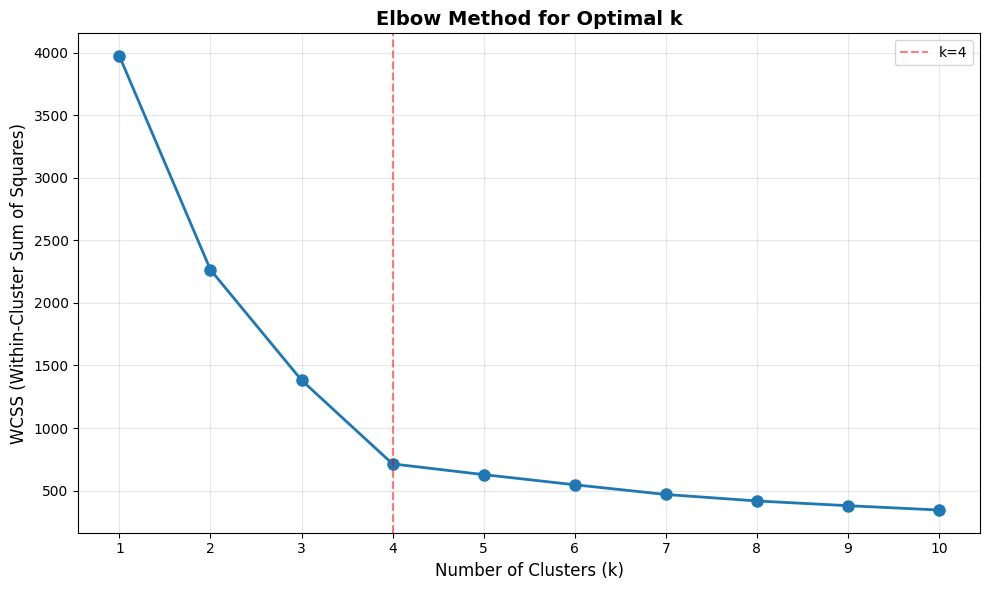

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.axvline(x=4, color='r', linestyle='--', alpha=0.5, label='k=4')
plt.legend()
plt.tight_layout()
plt.show()

WCSS values for each k:

In [22]:
for k, inertia in zip(k_range, wcss):
    print(f"k={k}: WCSS={inertia:.2f}")

k=1: WCSS=3972.33
k=2: WCSS=2264.40
k=3: WCSS=1382.37
k=4: WCSS=713.17
k=5: WCSS=627.70
k=6: WCSS=546.63
k=7: WCSS=469.04
k=8: WCSS=417.16
k=9: WCSS=379.33
k=10: WCSS=344.74


Silhouette method:

In [23]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_silhouette = range(2, 11)

for i in k_range_silhouette:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X, labels)
    silhouette_scores.append(silhouette_avg)
    print(f"k={i}: Silhouette Score={silhouette_avg:.4f}")

k=2: Silhouette Score=0.4132
k=3: Silhouette Score=0.4553
k=4: Silhouette Score=0.5251
k=5: Silhouette Score=0.4569
k=6: Silhouette Score=0.4103
k=7: Silhouette Score=0.3736
k=8: Silhouette Score=0.3738
k=9: Silhouette Score=0.3537
k=10: Silhouette Score=0.3396


Let's visualize.

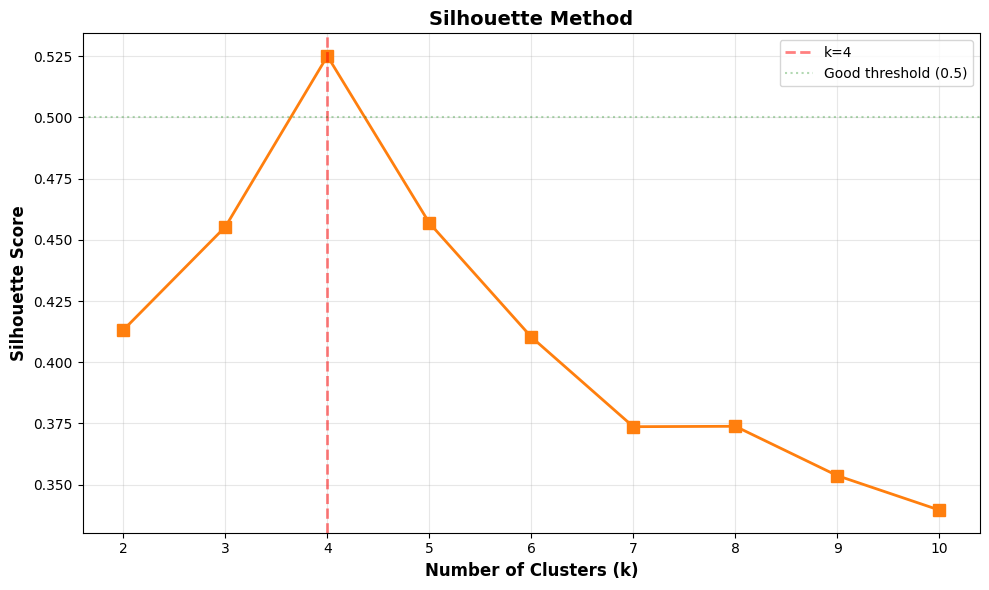

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(k_range_silhouette, silhouette_scores, marker='s', linestyle='-', 
         linewidth=2, markersize=8, color='tab:orange')
plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=12, fontweight='bold')
plt.title('Silhouette Method', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range_silhouette)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.5, linewidth=2, label='k=4')
plt.axhline(y=0.5, color='green', linestyle=':', alpha=0.3, label='Good threshold (0.5)')
plt.legend()

plt.tight_layout()
plt.show()

Back to the "make_blobs" function, but this time with other parameter values.

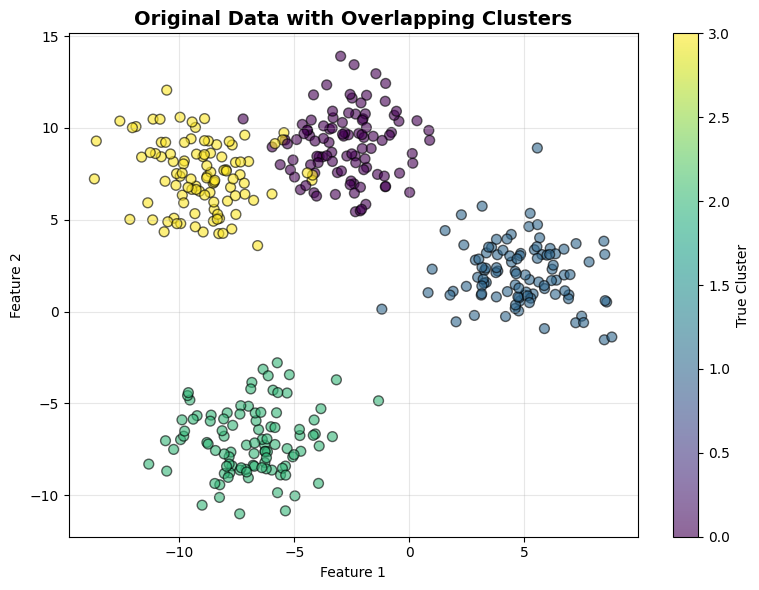

In [25]:
X, y = make_blobs(n_samples=400, centers=4, cluster_std=1.8, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6, edgecolors='k', s=50)
plt.title('Original Data with Overlapping Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='True Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Elbow method:

In [29]:
wcss = []
k_range_wcss = range(1, 11)

for i in k_range_wcss:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    print(f"k={i}: WCSS={kmeans.inertia_:.2f}")

k=1: WCSS=29521.30
k=2: WCSS=14784.51
k=3: WCSS=4583.02
k=4: WCSS=2395.13
k=5: WCSS=2155.27
k=6: WCSS=1924.15
k=7: WCSS=1697.36
k=8: WCSS=1471.22
k=9: WCSS=1316.06
k=10: WCSS=1207.43


Silhouette method:

In [30]:
silhouette_scores = []
k_range_silhouette = range(2, 11)

for i in k_range_silhouette:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X, labels)
    silhouette_scores.append(silhouette_avg)
    print(f"k={i}: Silhouette Score={silhouette_avg:.4f}")

k=2: Silhouette Score=0.5409
k=3: Silhouette Score=0.6697
k=4: Silhouette Score=0.6468
k=5: Silhouette Score=0.5932
k=6: Silhouette Score=0.5422
k=7: Silhouette Score=0.4332
k=8: Silhouette Score=0.3442
k=9: Silhouette Score=0.3597
k=10: Silhouette Score=0.3552


Now let's plot both methods:

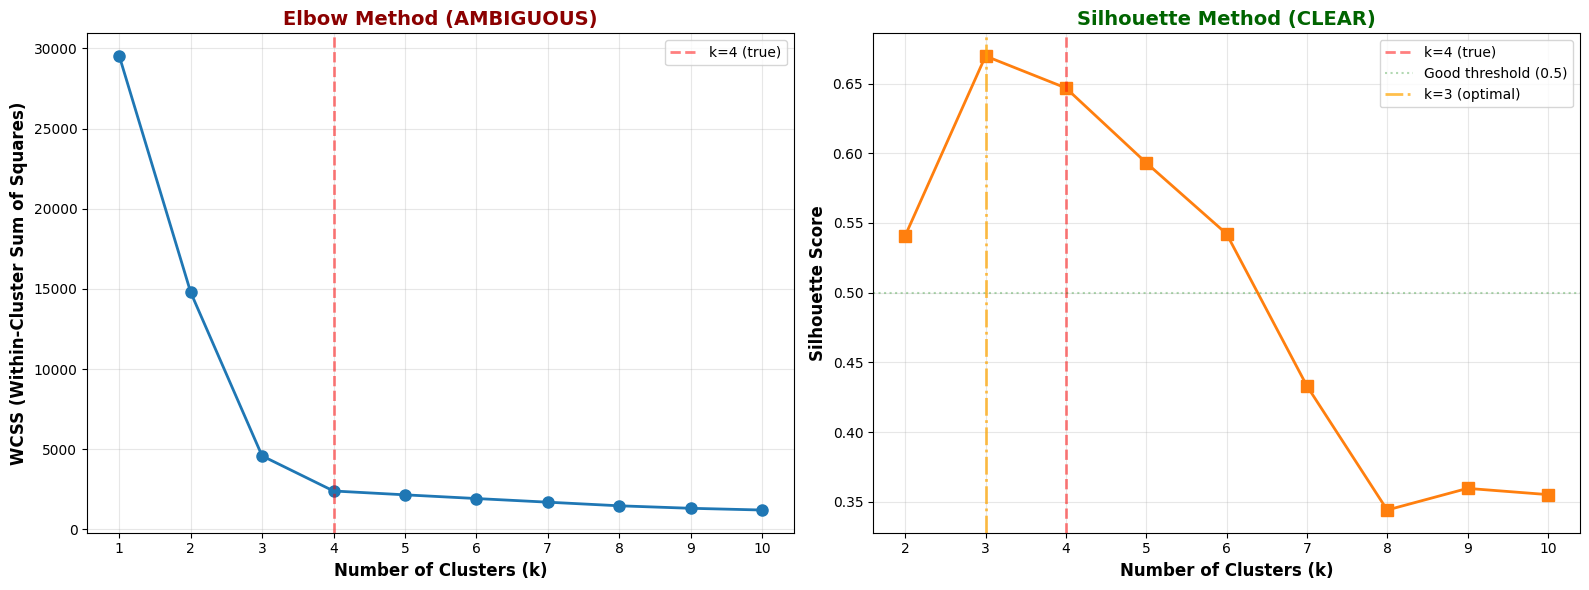

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(k_range_wcss, wcss, marker='o', linestyle='-', linewidth=2, 
         markersize=8, color='tab:blue')
ax1.set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12, fontweight='bold')
ax1.set_title('Elbow Method (AMBIGUOUS)', fontsize=14, fontweight='bold', color='darkred')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_range_wcss)
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.5, linewidth=2, label='k=4 (true)')
ax1.legend()

ax2.plot(k_range_silhouette, silhouette_scores, marker='s', linestyle='-', 
         linewidth=2, markersize=8, color='tab:orange')
ax2.set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
ax2.set_title('Silhouette Method (CLEAR)', fontsize=14, fontweight='bold', color='darkgreen')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(k_range_silhouette)
ax2.axvline(x=4, color='red', linestyle='--', alpha=0.5, linewidth=2, label='k=4 (true)')
ax2.axhline(y=0.5, color='green', linestyle=':', alpha=0.3, label='Good threshold (0.5)')
optimal_k = k_range_silhouette[silhouette_scores.index(max(silhouette_scores))]
ax2.axvline(x=optimal_k, color='orange', linestyle='-.', alpha=0.7, linewidth=2, label=f'k={optimal_k} (optimal)')
ax2.legend()

plt.tight_layout()
plt.show()